# 06 — Neuronpedia Feature Fingerprint Analysis

**No GPU required.** Run **top to bottom** once (first run fetches Neuronpedia labels, ~10–15 min).

Reads `top50_features` from the statistics JSONs, fetches Neuronpedia descriptions for every unique
`(layer, feat_idx)`, classifies them into six semantic categories, then computes **fingerprints**
(category proportions) per phase and produces the primary visualisations for §5B of the thesis.

| Phase | Stats file |
|-------|------------|
| `base` | `stats_base_v2.json` + `stats_base_v2_from160.json` merged (300 prompts, True/False order) |
| `base_v3` | `stats_base_v3.json` (90 prompts, **False or True** order — notebook **02c**) |
| `lora_l1` | `stats_lora_l1.json` (300 prompts) |
| `lora_l2` | `stats_lora_l2.json` (300 prompts) |
| `lora_l3_tri_num` | `stats_lora_l3_tri_num.json` (300 prompts) |

**Sections:**  
0. Paths · 1. Load stats · 2. Collect features · 3. Batch-fetch Neuronpedia ·
4. Inspect raw labels · 5. Category distribution · 6. Fingerprints (overall + True/False split) ·
7. Vis A — fingerprint bar chart · 8. Vis B — category × position heatmaps ·
9. Vis C — top-10 features per category · 10. Manual overrides · 11. Export outputs ·
12. **Paired base vs base_v3** (matched `tri_v2_*` ↔ `tri_v3_*`, tail-order ablation)

**Hypotheses tested (§5B):**  
H5 — base fingerprint dominated by `format-template`  
H5b — `base_v3` (False→True prompt ending) shifts fingerprint vs `base` (same model, different tail)  
H6 — after LoRA on triangle data, `geometry` proportion increases  
H7 — after LoRA on broad math, `math-general` increases (not `geometry`)  
H8 — `boolean-logic` increases after both fine-tuning runs


## 0 — Environment setup

In [1]:
import os
import sys
from pathlib import Path

def _find_repo_root():
    start = Path.cwd().resolve()
    for directory in [start, *start.parents]:
        if (directory / "circuit_tracer" / "__init__.py").is_file():
            return directory
    workspace = Path("/workspace")
    if workspace.is_dir():
        for child in workspace.iterdir():
            if child.is_dir() and (child / "circuit_tracer" / "__init__.py").is_file():
                return child
    repo_override = os.environ.get("CT_REPO_DIR")
    if repo_override:
        override_path = Path(repo_override).expanduser().resolve()
        if (override_path / "circuit_tracer" / "__init__.py").is_file():
            return override_path
    return None

_root = _find_repo_root()
if _root is not None:
    if str(_root) not in sys.path:
        sys.path.insert(0, str(_root))
    _my_work = _root / "my_work"
    if str(_my_work) not in sys.path:
        sys.path.insert(0, str(_my_work))
    print(f"Repo root : {_root}")
else:
    print("WARNING: could not locate circuit_tracer repo. Set CT_REPO_DIR env var.")

MY_WORK     = _my_work if _root else Path(".").resolve()
STATS_DIR   = MY_WORK / "results" / "statistics"
FIGURES_DIR = MY_WORK / "results" / "figures" / "neuronpedia"
CACHE_PATH  = MY_WORK / "cache" / "neuronpedia_cache.json"
OVERRIDES_PATH = MY_WORK / "cache" / "category_overrides.json"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print(f"MY_WORK     : {MY_WORK}")
print(f"STATS_DIR   : {STATS_DIR}")
print(f"FIGURES_DIR : {FIGURES_DIR}")
print(f"CACHE_PATH  : {CACHE_PATH}")


Repo root : /workspace/thesis_circuit_breaker
MY_WORK     : /workspace/thesis_circuit_breaker/my_work
STATS_DIR   : /workspace/thesis_circuit_breaker/my_work/results/statistics
FIGURES_DIR : /workspace/thesis_circuit_breaker/my_work/results/figures/neuronpedia
CACHE_PATH  : /workspace/thesis_circuit_breaker/my_work/cache/neuronpedia_cache.json


## 1 — Load statistics files

Registers five phases. **`base`** merges the two baseline v2 shards (same as notebook **05**):
`stats_base_v2.json` (prompts 001–159) + `stats_base_v2_from160.json` (160–300) → **300** prompts.

Also loads **`base_v3`** from notebook **02c** (`stats_base_v3.json`). Missing files are skipped with a warning.

In [2]:
import json
from pathlib import Path
from utils.graph_statistics import load_statistics

# ── Phase registry (value = one path or list of shard paths to merge) ───────────
PHASE_FILES: dict[str, Path | list[Path]] = {
    "base": [
        STATS_DIR / "stats_base_v2.json",
        STATS_DIR / "stats_base_v2_from160.json",
    ],
    "base_v3": STATS_DIR / "stats_base_v3.json",  # 02c: False-or-True tail order
    "lora_l1": STATS_DIR / "stats_lora_l1.json",
    "lora_l2": STATS_DIR / "stats_lora_l2.json",
    "lora_l3_tri_num": STATS_DIR / "stats_lora_l3_tri_num.json",
}


def _merge_shard_lists(*lists: list[dict]) -> list[dict]:
    """Merge stats shards by prompt_id (prefer succeeded over failed on conflict)."""
    merged: dict[str, dict] = {}
    for lst in lists:
        for row in lst:
            pid = row.get("prompt_id")
            if pid is None:
                continue
            if pid not in merged:
                merged[pid] = row
            else:
                old_ok = bool(merged[pid].get("attribution_succeeded"))
                new_ok = bool(row.get("attribution_succeeded"))
                if new_ok and not old_ok:
                    merged[pid] = row
                elif not old_ok and not new_ok:
                    merged[pid] = row
    return list(merged.values())


def _load_phase_entries(paths: Path | list[Path]) -> list[dict]:
    path_list = paths if isinstance(paths, list) else [paths]
    shards: list[list[dict]] = []
    for p in path_list:
        p = Path(p)
        if not p.exists():
            print(f"  WARNING: missing {p.name}")
            continue
        shards.append(load_statistics(p))
    if not shards:
        return []
    if len(shards) == 1:
        return shards[0]
    return _merge_shard_lists(*shards)


phase_stats: dict[str, list[dict]] = {}
for phase, paths in PHASE_FILES.items():
    entries = _load_phase_entries(paths)
    if not entries:
        print(f"WARNING: no data for phase '{phase}' — skipping")
        continue
    succeeded = [e for e in entries if e.get("attribution_succeeded")]
    phase_stats[phase] = entries
    shard_note = ""
    if phase == "base" and isinstance(paths, list):
        shard_note = f"  ({len(paths)} shards merged)"
    print(f"{phase:20s}: {len(entries):4d} total, {len(succeeded):4d} succeeded{shard_note}")

print(f"\nPhases loaded: {list(phase_stats.keys())}")


base                :  300 total,  300 succeeded  (2 shards merged)
base_v3             :   90 total,   90 succeeded
lora_l1             :  300 total,  300 succeeded
lora_l2             :  300 total,  300 succeeded
lora_l3_tri_num     :  300 total,  300 succeeded

Phases loaded: ['base', 'base_v3', 'lora_l1', 'lora_l2', 'lora_l3_tri_num']


## 2 — Collect unique (layer, feat_idx) pairs

Extracts every `(layer, feat_idx)` from `top50_features` across all phases.
Position (`pos`) is **not** part of the Neuronpedia cache key — position is per-prompt context,
not a property of the feature itself.

In [3]:
# Per-phase unique (layer, feat_idx)
phase_features: dict[str, set[tuple[int, int]]] = {}
all_features: set[tuple[int, int]] = set()

for phase, entries in phase_stats.items():
    feats: set[tuple[int, int]] = set()
    for e in entries:
        if not e.get("attribution_succeeded"):
            continue
        for triple in (e.get("top50_features") or []):
            layer, _pos, feat_idx = triple[0], triple[1], triple[2]
            feats.add((layer, feat_idx))
    phase_features[phase] = feats
    all_features |= feats
    print(f"{phase:20s}: {len(feats):4d} unique (layer, feat_idx) pairs")

print(f"\nAll phases combined: {len(all_features)} unique pairs to look up")


base                :  282 unique (layer, feat_idx) pairs
base_v3             :   90 unique (layer, feat_idx) pairs
lora_l1             :  289 unique (layer, feat_idx) pairs
lora_l2             :  290 unique (layer, feat_idx) pairs
lora_l3_tri_num     :  752 unique (layer, feat_idx) pairs

All phases combined: 1007 unique pairs to look up


## 3 — Batch-fetch Neuronpedia labels

Uses `utils/neuronpedia.py` → `fetch_and_cache_batch`.  
Rate-limited to ≥ 0.5 s between requests; cache written every 10 new fetches.  
**First run**: ~10–15 min. **Subsequent runs**: instant (all served from cache).

Neuronpedia endpoint:  
`GET https://www.neuronpedia.org/api/feature/gemma-2-2b/{layer}-gemmascope-transcoder-16k/{feat_idx}`

In [4]:
import json
from utils.neuronpedia import load_cache, save_cache, fetch_and_cache_batch

# Load manual overrides (empty dict if file is missing or empty)
override_map: dict = {}
if OVERRIDES_PATH.exists():
    with open(OVERRIDES_PATH) as f:
        override_map = json.load(f) or {}
print(f"Overrides loaded: {len(override_map)} entries")

cache = load_cache(CACHE_PATH)
already_cached = len(cache)
to_fetch = [pair for pair in all_features if f"{pair[0]}_{pair[1]}" not in cache]
print(f"Cache: {already_cached} existing entries, {len(to_fetch)} new fetches needed")

if to_fetch:
    print("Fetching from Neuronpedia (this will take a while on first run)...")
    cache = fetch_and_cache_batch(
        list(all_features), cache, CACHE_PATH, override_map=override_map
    )
    print(f"Fetch complete. Cache now has {len(cache)} entries.")
else:
    print("All features already cached — no network requests needed.")


Overrides loaded: 0 entries
Cache: 1004 existing entries, 3 new fetches needed
Fetching from Neuronpedia (this will take a while on first run)...
Fetch complete. Cache now has 1007 entries.


## 4 — Inspect raw labels

Sanity-check: print a random sample of the fetched Neuronpedia labels per phase.
Use this section to spot misclassifications before proceeding to Section 10 (overrides).

In [5]:
import random
import pandas as pd

SAMPLE_N = 15  # features to sample per phase
random.seed(42)

for phase, feats in phase_features.items():
    sample = random.sample(sorted(feats), min(SAMPLE_N, len(feats)))
    rows = []
    for layer, feat_idx in sorted(sample):
        key = f"{layer}_{feat_idx}"
        entry = cache.get(key, {})
        rows.append({
            "layer": layer,
            "feat_idx": feat_idx,
            "label": entry.get("label", "(missing)"),
            "category": entry.get("category", "?"),
            "top_tokens": ", ".join((entry.get("top_tokens") or [])[:5]),
        })
    df = pd.DataFrame(rows)
    print(f"\n=== {phase} (sample of {len(rows)}) ===")
    pd.set_option("display.max_colwidth", 80)
    display(df)



=== base (sample of 15) ===


,layer,feat_idx,label,category,top_tokens
0,0,3063,inequality symbols in mathematical/scientific text,math-general,
1,0,3236,"the number ""two""",math-general,
2,0,3255,"the word ""and""",other,
3,0,9193,"phrases that suggest debt, obligation, sentiment, or dependency",other,
4,0,10219,"the indefinite article ""a""",other,
5,0,10935,"the word ""mode""",other,
6,0,11504,the word 'series' and other words surrounding it related to importance or d...,other,
7,0,13004,"parenthetical numerical references and citations to literature, laws, and st...",other,
8,3,430,"words related to arguing, explaining or critical thinking including words a...",other,
9,3,5223,"auxiliary (helping) verbs like ""to be"", ""to have"", and ""can"".",other,



=== base_v3 (sample of 15) ===


,layer,feat_idx,label,category,top_tokens
0,0,545,"the word ""symptoms.""",other,
1,0,3145,"the word ""there""",other,
2,0,10815,"the word ""any"".",other,
3,0,11570,"the word ""be"" and words that can be associated with obligation",other,
4,0,11966,"mentions of the word ""heart.""",other,
5,0,16200,code syntax elements,format-template,
6,9,766,technical writing with numerical percentages,other,
7,16,10288,question prompts that have numerical or mathematical components,math-general,
8,18,15770,truth and true,boolean-logic,
9,21,651,assertions and reasoning.,boolean-logic,



=== lora_l1 (sample of 15) ===


,layer,feat_idx,label,category,top_tokens
0,0,6176,mathematical equations and theorems,math-general,
1,0,11802,"mathematical expressions, specifically those involving division, remainders...",math-general,
2,0,11966,"mentions of the word ""heart.""",other,
3,0,12370,periods that end sentences and decimal points preceding numbers,math-general,
4,2,5437,"occurrences of the word ""answer"" and related words like ""questions""",format-template,
5,12,6309,yes or no questions,format-template,
6,17,11405,false,boolean-logic,
7,18,1272,words and phrases related to disagreement or being proven wrong,other,
8,19,10926,"code snippets and associated descriptive terms like ""string"", ""value"", and ...",math-general,
9,19,15573,java code defining variable assignments based on property values,other,



=== lora_l2 (sample of 15) ===


,layer,feat_idx,label,category,top_tokens
0,0,7193,"strings of digits, especially years or measurement values, often containing...",other,
1,0,10345,titles of creative works or legal documents,other,
2,0,11167,mentions of financial funds or offices,other,
3,0,12799,"the word ""relative"" and potentially words that modify or are otherwise near it",other,
4,0,16116,"the term ""there""",other,
5,8,16120,mathematical statements,math-general,
6,17,6448,True,boolean-logic,
7,17,9211,code snippets including assignment and comparison operators,language-comparative,
8,19,8274,"technical language related to research and development, particularly about ...",other,
9,19,10159,various aspects of research papers and formatted numerical data,format-template,



=== lora_l3_tri_num (sample of 15) ===


,layer,feat_idx,label,category,top_tokens
0,0,12370,periods that end sentences and decimal points preceding numbers,math-general,
1,14,6750,what appears to be garbage or noise in the text.,other,
2,17,824,numerical data,other,
3,18,11823,"numbers or number-like strings, and sometimes surrounding words",math-general,
4,19,263,"numbers, calculations and references to figures",math-general,
5,20,4154,"numerical codes, names, and formatting relating to computer files and progra...",format-template,
6,20,5737,descriptors and quantifiers,other,
7,20,6448,seemingly random numbers,math-general,
8,21,13102,"code snippets, numbers, and characters often related to technical or mathem...",math-general,
9,24,3437,numbers surrounded by other characters,math-general,


## 5 — Category distribution

Show the raw count of each category across all features in each phase's `top50_features`.

In [6]:
from collections import defaultdict, Counter
from utils.feature_categorizer import categorize_label, apply_category_overrides

CATEGORIES = ["geometry", "boolean-logic", "language-comparative",
              "math-general", "format-template", "other"]

def _get_category(layer: int, feat_idx: int) -> str:
    """Look up category from cache, applying overrides."""
    key = f"{layer}_{feat_idx}"
    entry = cache.get(key, {})
    cat = entry.get("category") or categorize_label(entry.get("label", ""))
    return apply_category_overrides(layer, feat_idx, cat, override_map)

# Appearance counts: each (layer, pos, feat_idx) occurrence in top50_features counts once
phase_cat_counts: dict[str, Counter] = {}
for phase, entries in phase_stats.items():
    counts: Counter = Counter()
    for e in entries:
        if not e.get("attribution_succeeded"):
            continue
        for triple in (e.get("top50_features") or []):
            layer, _pos, feat_idx = triple[0], triple[1], triple[2]
            counts[_get_category(layer, feat_idx)] += 1
    phase_cat_counts[phase] = counts

# Summary table
rows = []
for phase, counts in phase_cat_counts.items():
    total = sum(counts.values())
    row = {"phase": phase, "total_appearances": total}
    for cat in CATEGORIES:
        row[cat] = counts.get(cat, 0)
        row[f"{cat}_%"] = round(100 * counts.get(cat, 0) / total, 1) if total else 0
    rows.append(row)

df_counts = pd.DataFrame(rows).set_index("phase")
print("Category appearance counts across top50_features per phase:")
display(df_counts[["total_appearances"] + CATEGORIES])
print("\nPercentages:")
display(df_counts[[f"{c}_%" for c in CATEGORIES]])


Category appearance counts across top50_features per phase:


,total_appearances,geometry,boolean-logic,language-comparative,math-general,format-template,other
phase,,,,,,,
base,15000,636,2569,241,3647,2429,5478
base_v3,4500,67,1404,0,1265,390,1374
lora_l1,15000,437,3151,162,3412,1771,6067
lora_l2,15000,338,3236,226,3179,2074,5947
lora_l3_tri_num,15000,674,1677,139,6040,844,5626



Percentages:


,geometry_%,boolean-logic_%,language-comparative_%,math-general_%,format-template_%,other_%
phase,,,,,,
base,4.2,17.1,1.6,24.3,16.2,36.5
base_v3,1.5,31.2,0.0,28.1,8.7,30.5
lora_l1,2.9,21.0,1.1,22.7,11.8,40.4
lora_l2,2.3,21.6,1.5,21.2,13.8,39.6
lora_l3_tri_num,4.5,11.2,0.9,40.3,5.6,37.5


## 6 — Fingerprints (overall + True/False split)

Compute one fingerprint per phase (category proportions, summing to 1).  
Also split by `label` (True vs False prompts) to test H5/H8.

In [7]:
from utils.feature_categorizer import compute_fingerprint

# ── Overall fingerprints ───────────────────────────────────────────────────────
fingerprints: dict[str, dict] = {}
for phase, entries in phase_stats.items():
    fingerprints[phase] = compute_fingerprint(entries, cache, override_map=override_map)

df_fp = pd.DataFrame(fingerprints).T[CATEGORIES]
df_fp = df_fp.round(4)
print("Overall fingerprints (proportion per category):")
display(df_fp)

# ── True/False split ───────────────────────────────────────────────────────────
fp_split: dict[str, dict] = {}  # keys like "base/True", "base/False"

for phase, entries in phase_stats.items():
    for label_val in [True, False]:
        subset = [
            e for e in entries
            if e.get("attribution_succeeded")
            and bool(e.get("label")) == label_val
        ]
        if subset:
            fp_split[f"{phase}/{'True' if label_val else 'False'}"] = (
                compute_fingerprint(subset, cache, override_map=override_map)
            )

df_split = pd.DataFrame(fp_split).T[CATEGORIES].round(4)
print("\nFingerprints split by label (True/False):")
display(df_split)


Overall fingerprints (proportion per category):


,geometry,boolean-logic,language-comparative,math-general,format-template,other
base,0.0424,0.1713,0.0161,0.2431,0.1619,0.3652
base_v3,0.0149,0.3120,0.0000,0.2811,0.0867,0.3053
lora_l1,0.0291,0.2101,0.0108,0.2275,0.1181,0.4045
lora_l2,0.0225,0.2157,0.0151,0.2119,0.1383,0.3965
lora_l3_tri_num,0.0449,0.1118,0.0093,0.4027,0.0563,0.3751



Fingerprints split by label (True/False):


,geometry,boolean-logic,language-comparative,math-general,format-template,other
base/True,0.0379,0.1555,0.0137,0.2644,0.1753,0.3532
base/False,0.0479,0.1905,0.0190,0.2172,0.1456,0.3799
base_v3/True,0.0240,0.3084,0.0000,0.2822,0.0840,0.3013
base_v3/False,0.0058,0.3156,0.0000,0.2800,0.0893,0.3093
lora_l1/True,0.0313,0.1925,0.0085,0.2448,0.1233,0.3996
lora_l1/False,0.0265,0.2316,0.0136,0.2062,0.1117,0.4104
lora_l2/True,0.0241,0.1972,0.0152,0.2399,0.1400,0.3836
lora_l2/False,0.0206,0.2384,0.0150,0.1778,0.1361,0.4121
lora_l3_tri_num/True,0.0401,0.1046,0.0098,0.4127,0.0573,0.3754
lora_l3_tri_num/False,0.0508,0.1206,0.0086,0.3904,0.0550,0.3747


## 7 — Visualisation A: Fingerprint bar chart

Grouped bar chart: categories on x-axis, phases as bar groups.  
Saved to `results/figures/neuronpedia/fingerprint_bar.png`.

Saved: /workspace/thesis_circuit_breaker/my_work/results/figures/neuronpedia/fingerprint_bar.png


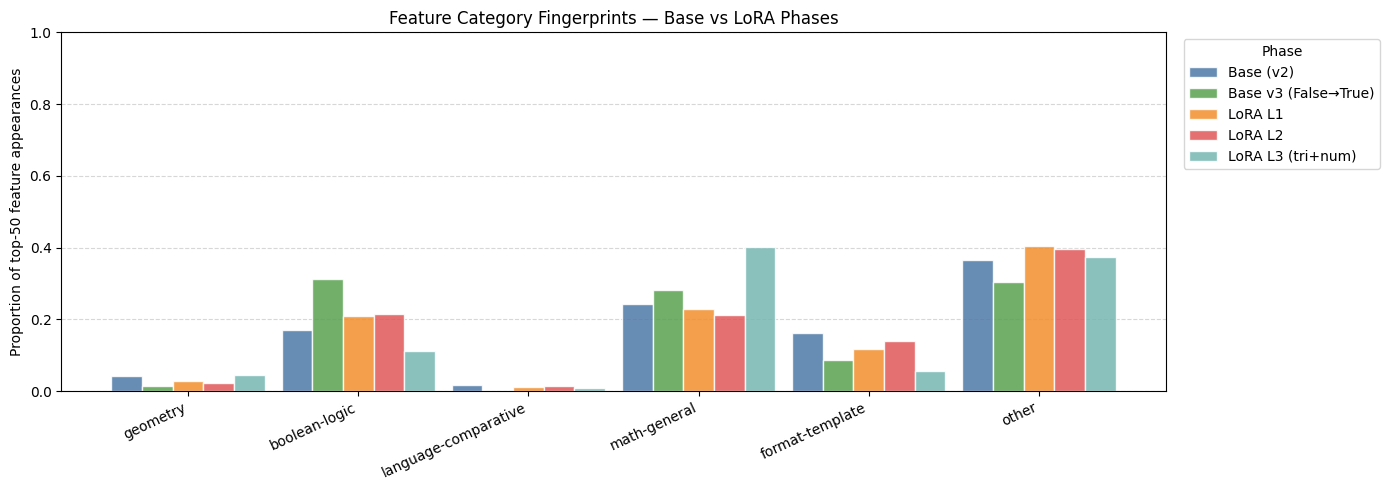

In [19]:
import matplotlib.pyplot as plt
import numpy as np

PHASE_LABELS = {
    "base":            "Base (v2)",
    "base_v3":         "Base v3 (False→True)",
    "lora_l1":         "LoRA L1",
    "lora_l2":         "LoRA L2",
    "lora_l3_tri_num": "LoRA L3 (tri+num)",
}
# One color per phase (legend = phase). CAT_COLORS is for stacked chart (§7b) only.
PHASE_COLORS = {
    "base":            "#4e79a7",
    "base_v3":         "#59a14f",
    "lora_l1":         "#f28e2b",
    "lora_l2":         "#e15759",
    "lora_l3_tri_num": "#76b7b2",
}
CAT_COLORS = {
    "geometry":            "#4e79a7",
    "boolean-logic":       "#f28e2b",
    "language-comparative":"#e15759",
    "math-general":        "#76b7b2",
    "format-template":     "#59a14f",
    "other":               "#b0b0b0",
}

phases = list(fingerprints.keys())
x = np.arange(len(CATEGORIES))
n_phases = len(phases)
width = 0.18
offsets = np.linspace(-(n_phases - 1) / 2, (n_phases - 1) / 2, n_phases) * width

from matplotlib.patches import Patch

fig, ax = plt.subplots(figsize=(14, 5))
for i, phase in enumerate(phases):
    vals = [fingerprints[phase].get(cat, 0) for cat in CATEGORIES]
    ax.bar(
        x + offsets[i], vals, width,
        color=PHASE_COLORS.get(phase, f"C{i}"),
        alpha=0.9,
        edgecolor="white",
        linewidth=0.8,
    )

ax.set_xticks(x)
ax.set_xticklabels(CATEGORIES, rotation=30, ha="right", fontsize=10)
ax.set_ylabel("Proportion of top-50 feature appearances")
ax.set_title("Feature Category Fingerprints — Base vs LoRA Phases")
ax.set_ylim(0, 1)
ax.legend(
    handles=[
        Patch(facecolor=PHASE_COLORS[p], edgecolor="white", label=PHASE_LABELS[p])
        for p in phases if p in PHASE_COLORS
    ],
    title="Phase",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
)
ax.yaxis.grid(True, linestyle="--", alpha=0.5)
ax.set_axisbelow(True)

fig.tight_layout()
out_path = FIGURES_DIR / "fingerprint_bar.png"
fig.savefig(out_path, dpi=150, bbox_inches="tight")
print(f"Saved: {out_path}")
plt.show()


> **Neuronpedia fingerprint chart — short interpretation**
>
> **What the chart shows**  
> For each model phase (base v2, base v3 with “False or True” tail, and three LoRA runs), we count how often top-attribution features fall into six Neuronpedia keyword categories. Each bar is the **share of top-50 feature slots** in that category (flat count, not weighted by attribution score).
>
> **What we see**
> - **`other` is large everywhere (~30–40%)** — many top features don’t match our geometry/math/format keywords.
> - **`geometry` and `language-comparative` are tiny** — triangle/geometry and comparative language are rarely among the strongest features in this setup.
> - **`boolean-logic` is highest for base v3 (~31%)** — reversing the answer tail to “False or True” pushes more truth/logic-labelled features into the top set.
> - **`math-general` jumps for LoRA L3 (~40%)** — the triangle+numeric LoRA run is dominated by general math/number features in the top-50 mix.
> - **`format-template` is strongest on base v2 (~16%) and weakest on LoRA L3 (~5%)** — instruction/format features matter more before that fine-tune and less after L3.
> - **LoRA L1/L2 sit between base and L3** on boolean and math, without the extreme L3 math peak or the base v3 boolean peak.
>
> **Key takeaways**
> 1. **Tail wording changes the semantic mix without retraining** — base v3 vs base v2 shifts mass toward boolean-logic, not geometry.  
> 2. **LoRA L3 changes the circuit’s “topic” more than L1/L2** — especially toward math-general, away from format-template.  
> 3. **No phase looks “triangle-native” in the top-50** — geometry stays a small slice; the model leans on generic math, logic, and catch-all features.  
> 4. **Compare phases on the same prompt set** — base v2 should use the merged 300-prompt stats; base v3 is only 90 prompts, so treat it as a tail-order ablation, not a full parallel to LoRA’s 300.

### 7b — Stacked bar chart (alternative view)

Each phase is a single bar; categories stacked to show the full composition at a glance.

Saved: /workspace/thesis_circuit_breaker/my_work/results/figures/neuronpedia/fingerprint_stacked.png


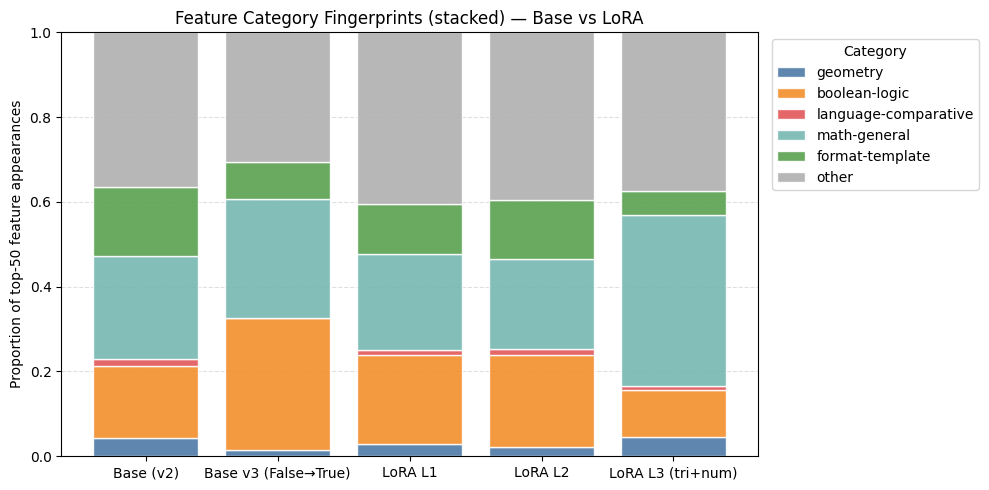

In [9]:
fig, ax = plt.subplots(figsize=(10, 5))
phase_display = [PHASE_LABELS.get(p, p) for p in phases]
bottoms = np.zeros(len(phases))

for cat in CATEGORIES:
    vals = np.array([fingerprints[p].get(cat, 0) for p in phases])
    ax.bar(phase_display, vals, bottom=bottoms, label=cat,
           color=CAT_COLORS[cat], edgecolor="white", alpha=0.9)
    bottoms += vals

ax.set_ylabel("Proportion of top-50 feature appearances")
ax.set_title("Feature Category Fingerprints (stacked) — Base vs LoRA")
ax.set_ylim(0, 1)
ax.legend(title="Category", bbox_to_anchor=(1.01, 1), loc="upper left")
ax.yaxis.grid(True, linestyle="--", alpha=0.4)
ax.set_axisbelow(True)

fig.tight_layout()
out_path = FIGURES_DIR / "fingerprint_stacked.png"
fig.savefig(out_path, dpi=150, bbox_inches="tight")
print(f"Saved: {out_path}")
plt.show()


## 8 — Visualisation B: Category × token-position heatmaps

For each phase: a heatmap with categories on the y-axis and token positions (0–29) on the x-axis.  
Cells show normalised count of feature appearances at each (category, position).

Key question: does `format-template` shift away from pos=21 (Answer: slot) toward content
token positions (pos 5–18) after fine-tuning?

/tmp/ipykernel_1460/1775565431.py:22: RuntimeWarning: invalid value encountered in divide
  matrix_norm = np.where(row_sums > 0, matrix / row_sums, 0)


Saved: /workspace/thesis_circuit_breaker/my_work/results/figures/neuronpedia/position_heatmap_grid.png


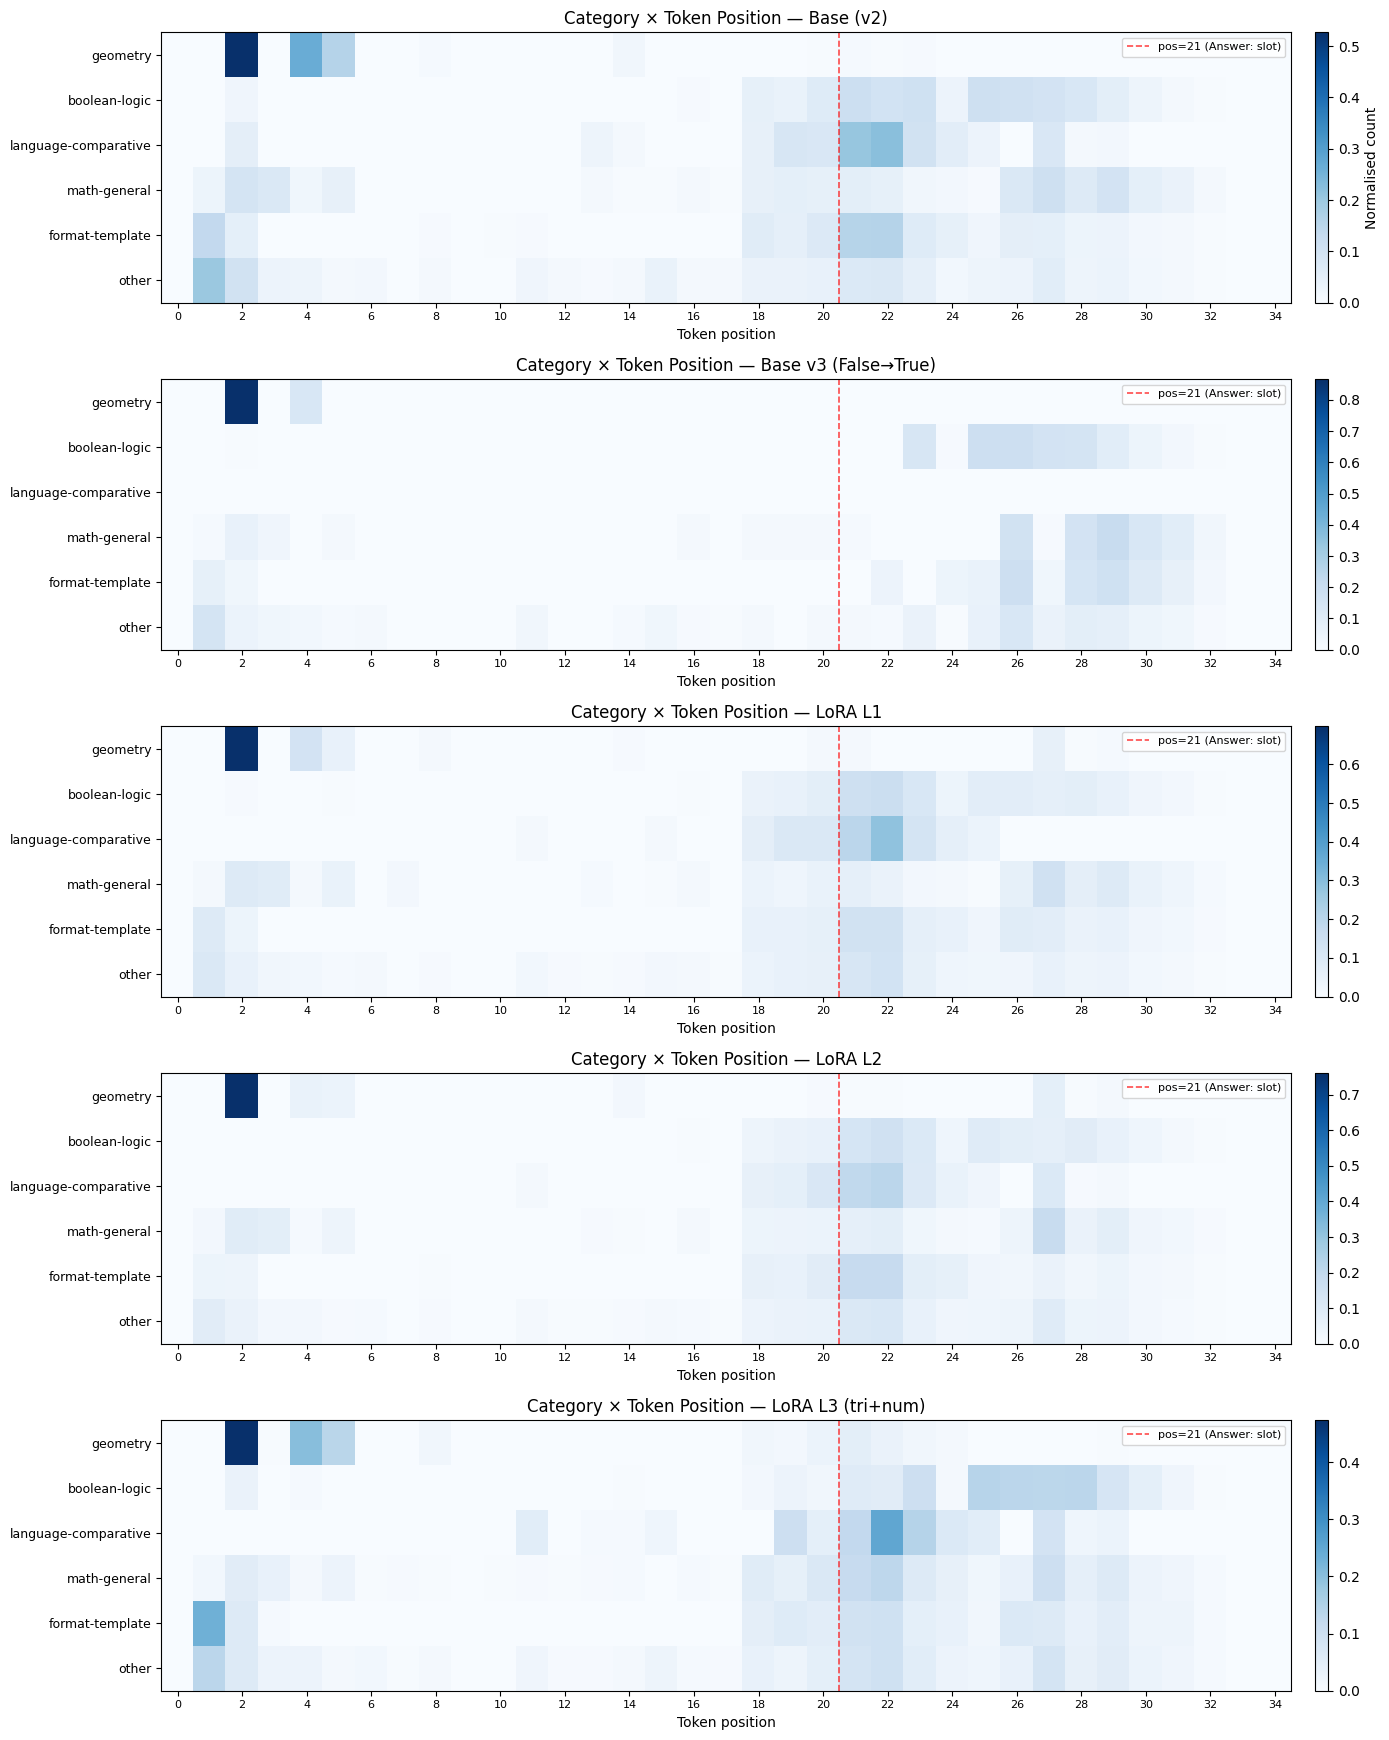

In [21]:
import matplotlib.pyplot as plt
import numpy as np
from utils.feature_categorizer import compute_position_heatmap

MAX_POS = 35  # show positions 0–34; extend if prompts are longer

# Precompute all matrices for each phase
matrices = []
titles = []
for phase, entries in phase_stats.items():
    pos_data = compute_position_heatmap(entries, cache, override_map=override_map)

    # Build matrix: rows = categories, cols = positions
    matrix = np.zeros((len(CATEGORIES), MAX_POS))
    for r, cat in enumerate(CATEGORIES):
        for pos, count in (pos_data.get(cat) or {}).items():
            if pos < MAX_POS:
                matrix[r, pos] = count

    # Normalise each row to 0-1 (proportion across positions)
    row_sums = matrix.sum(axis=1, keepdims=True)
    matrix_norm = np.where(row_sums > 0, matrix / row_sums, 0)
    matrices.append(matrix_norm)
    titles.append(PHASE_LABELS.get(phase, phase))

# Create a single column of subplots, one per phase
n_phases = len(matrices)
fig, axes = plt.subplots(nrows=n_phases, ncols=1, figsize=(14, 3.5 * n_phases), squeeze=False)

for i, (matrix_norm, title) in enumerate(zip(matrices, titles)):
    ax = axes[i, 0]
    im = ax.imshow(matrix_norm, aspect="auto", cmap="Blues", vmin=0, vmax=matrix_norm.max() or 1)
    ax.set_yticks(range(len(CATEGORIES)))
    ax.set_yticklabels(CATEGORIES, fontsize=9)
    ax.set_xticks(range(0, MAX_POS, 2))
    ax.set_xticklabels(range(0, MAX_POS, 2), fontsize=8)
    ax.set_xlabel("Token position")
    ax.set_title(f"Category × Token Position — {title}")
    if i == 0:
        cb = plt.colorbar(im, ax=ax, fraction=0.025, pad=0.02, label="Normalised count")
    else:
        plt.colorbar(im, ax=ax, fraction=0.025, pad=0.02)
    ax.axvline(x=21 - 0.5, color="red", linewidth=1.2, linestyle="--", alpha=0.7,
               label="pos=21 (Answer: slot)")
    ax.legend(loc="upper right", fontsize=8)
    ax.yaxis.grid(False)
    ax.xaxis.grid(False)

fig.tight_layout()
out_path = FIGURES_DIR / "position_heatmap_grid.png"
fig.savefig(out_path, dpi=150, bbox_inches="tight")
print(f"Saved: {out_path}")
plt.show()


> **Category × position heatmaps — short interpretation**
>
> **What the charts show**  
> For each phase, we plot **where** top-50 features sit in the prompt (token position 0–34) and **what** Neuronpedia category they get. Each row is a category; color = share of that category’s activations at that position (normalized within the row, so the darkest cell is “where this category shows up most”).
>
> The red dashed line at **position 21** marks the **“Answer:” slot** — the word the model must predict (True/False).
>
> **What we see**
> - **Early spike at position ~2 (`geometry`)** — all phases show their strongest geometry signal near the start of the claim (side lengths / triangle wording), not at the answer token.
> - **Quiet middle (roughly positions 6–20)** — few top features in the body of the prompt; most action is **early** or **late**.
> - **After the answer slot (21+)** — most boolean, math, format, and “other” features cluster on the **tail** of the prompt (positions ~22–30), i.e. near “True or False” / “False or True”.
> - **Base v2** — broad late activity across boolean, language-comparative, and math after pos 21 (many categories light up together).
> - **Base v3 (False→True)** — **sparser** overall; late activity is narrower (mainly boolean + math bands), matching a more format/logic-heavy fingerprint.
> - **LoRA L1 / L2** — similar late pattern: bumps in **language-comparative** (~22–23) and **math-general** (~27–29); geometry still early.
> - **LoRA L3 (tri+num)** — more early-token spread (positions 0–5, including format-template); after 21, a **sharp** language-comparative peak at ~22 and sustained boolean/math through ~25–30.
>
> **Key takeaways**
> 1. **Position and category tell different stories** — “geometry” features track **content tokens** (early); boolean/math/format track the **decision tail** (late).  
> 2. **The answer slot is a hinge** — little top-feature mass sits on pos 21 itself; influence is **before** (claim) or **after** (answer instruction + label region).  
> 3. **Changing only the tail order (base v3)** compresses *where* categories appear late — same model, less diffuse post-21 activity than base v2.  
> 4. **LoRA L3 shifts some mass to the very first tokens** — consistent with learning numeric/triangle + answer-format cues, not only the final word.  
> 5. **Heatmaps complement the bar chart** — bars say *how much* of each category; heatmaps say *at which tokens* that mass lives (early claim vs answer tail).

## 9 — Visualisation C: Top-10 features per category

For each phase, list the 10 most frequently appearing `(layer, feat_idx)` pairs in each category,
with their Neuronpedia labels and clickable dashboard URLs.  
Provides qualitative grounding for the fingerprint numbers.

In [11]:
from IPython.display import Markdown, display as ipy_display
from utils.feature_categorizer import get_top_features_by_category

NP_URL_TEMPLATE = (
    "https://www.neuronpedia.org/gemma-2-2b/{layer}-gemmascope-transcoder-16k/{feat_idx}"
)
TOP_N = 10

all_top_rows = []  # for CSV export in Section 11

for phase, entries in phase_stats.items():
    ipy_display(Markdown(f"### Phase: {PHASE_LABELS.get(phase, phase)}"))
    for cat in CATEGORIES:
        top = get_top_features_by_category(
            entries, cache, cat, n=TOP_N, override_map=override_map
        )
        if not top:
            continue
        rows_md = ["| Layer | feat_idx | Count | Label | URL |"]
        rows_md.append("|-------|----------|-------|-------|-----|")
        for r in top:
            url = NP_URL_TEMPLATE.format(layer=r["layer"], feat_idx=r["feat_idx"])
            label_trunc = (r["label"] or "")[:80]
            rows_md.append(
                f"| {r['layer']} | {r['feat_idx']} | {r['count']} "
                f"| {label_trunc} | [↗]({url}) |"
            )
            all_top_rows.append({
                "phase": phase, "category": cat,
                "layer": r["layer"], "feat_idx": r["feat_idx"],
                "count": r["count"], "label": r["label"],
                "url": url,
            })
        ipy_display(Markdown(f"**{cat}**\n" + "\n".join(rows_md) + "\n"))


### Phase: Base (v2)

**geometry**
| Layer | feat_idx | Count | Label | URL |
|-------|----------|-------|-------|-----|
| 1 | 161 | 149 |  technical descriptions of geometric objects and their properties | [↗](https://www.neuronpedia.org/gemma-2-2b/1-gemmascope-transcoder-16k/161) |
| 0 | 14217 | 133 | words with a positive valence and also identifies different sides in a political | [↗](https://www.neuronpedia.org/gemma-2-2b/0-gemmascope-transcoder-16k/14217) |
| 0 | 8254 | 97 | the word 'sides' | [↗](https://www.neuronpedia.org/gemma-2-2b/0-gemmascope-transcoder-16k/8254) |
| 0 | 11224 | 82 | the word "sides," potentially in the context of opposing viewpoints or groups | [↗](https://www.neuronpedia.org/gemma-2-2b/0-gemmascope-transcoder-16k/11224) |
| 0 | 15296 | 67 |  the word "sides" | [↗](https://www.neuronpedia.org/gemma-2-2b/0-gemmascope-transcoder-16k/15296) |
| 0 | 13329 | 52 | mentions of flat shapes with measurable, geometric sides. | [↗](https://www.neuronpedia.org/gemma-2-2b/0-gemmascope-transcoder-16k/13329) |
| 2 | 8581 | 19 | the word "sides" | [↗](https://www.neuronpedia.org/gemma-2-2b/2-gemmascope-transcoder-16k/8581) |
| 6 | 8248 | 14 |  words related to geometric shapes and mathematical analysis | [↗](https://www.neuronpedia.org/gemma-2-2b/6-gemmascope-transcoder-16k/8248) |
| 16 | 10626 | 13 |  words and phrases related to measuring angles or distances, especially those us | [↗](https://www.neuronpedia.org/gemma-2-2b/16-gemmascope-transcoder-16k/10626) |
| 1 | 745 | 10 |  the word "side" | [↗](https://www.neuronpedia.org/gemma-2-2b/1-gemmascope-transcoder-16k/745) |


**boolean-logic**
| Layer | feat_idx | Count | Label | URL |
|-------|----------|-------|-------|-----|
| 4 | 12613 | 266 |  words and phrases that have to do with truth | [↗](https://www.neuronpedia.org/gemma-2-2b/4-gemmascope-transcoder-16k/12613) |
| 21 | 7787 | 181 |  mathematical language, including variables, equations, and logical deductions | [↗](https://www.neuronpedia.org/gemma-2-2b/21-gemmascope-transcoder-16k/7787) |
| 2 | 1499 | 180 | the boolean value "True" | [↗](https://www.neuronpedia.org/gemma-2-2b/2-gemmascope-transcoder-16k/1499) |
| 24 | 4640 | 179 |  text indicating assertions of truth or falsity | [↗](https://www.neuronpedia.org/gemma-2-2b/24-gemmascope-transcoder-16k/4640) |
| 21 | 651 | 173 | assertions and reasoning. | [↗](https://www.neuronpedia.org/gemma-2-2b/21-gemmascope-transcoder-16k/651) |
| 17 | 11405 | 170 | false | [↗](https://www.neuronpedia.org/gemma-2-2b/17-gemmascope-transcoder-16k/11405) |
| 23 | 7446 | 156 |  negative responses, code-related instructions, and conditional statements | [↗](https://www.neuronpedia.org/gemma-2-2b/23-gemmascope-transcoder-16k/7446) |
| 18 | 2940 | 149 |  clauses expressing an opinion or whether something is true | [↗](https://www.neuronpedia.org/gemma-2-2b/18-gemmascope-transcoder-16k/2940) |
| 21 | 13859 | 128 |  code snippets that have properties like "true" or "false" and return values | [↗](https://www.neuronpedia.org/gemma-2-2b/21-gemmascope-transcoder-16k/13859) |
| 24 | 8991 | 90 |  code snippets in various languages likely to define boolean logic | [↗](https://www.neuronpedia.org/gemma-2-2b/24-gemmascope-transcoder-16k/8991) |


**language-comparative**
| Layer | feat_idx | Count | Label | URL |
|-------|----------|-------|-------|-----|
| 9 | 1653 | 209 |  questions, answers, and instructions involving one or more choices, particularl | [↗](https://www.neuronpedia.org/gemma-2-2b/9-gemmascope-transcoder-16k/1653) |
| 22 | 15283 | 24 | numerical problems, like calculations and comparisons | [↗](https://www.neuronpedia.org/gemma-2-2b/22-gemmascope-transcoder-16k/15283) |
| 0 | 15094 | 8 | ordinal numbers, and in particular the word "third." | [↗](https://www.neuronpedia.org/gemma-2-2b/0-gemmascope-transcoder-16k/15094) |


**math-general**
| Layer | feat_idx | Count | Label | URL |
|-------|----------|-------|-------|-----|
| 0 | 6051 | 310 | periods, spaces, and the number 1 | [↗](https://www.neuronpedia.org/gemma-2-2b/0-gemmascope-transcoder-16k/6051) |
| 0 | 11805 | 272 |  mathematical equations often containing trigonometric functions | [↗](https://www.neuronpedia.org/gemma-2-2b/0-gemmascope-transcoder-16k/11805) |
| 25 | 4882 | 235 |  math problems and related terms like "derivative" and "term" | [↗](https://www.neuronpedia.org/gemma-2-2b/25-gemmascope-transcoder-16k/4882) |
| 23 | 5188 | 209 | mathematical and academic references and structures | [↗](https://www.neuronpedia.org/gemma-2-2b/23-gemmascope-transcoder-16k/5188) |
| 24 | 1764 | 206 |  mathematical equations and expressions | [↗](https://www.neuronpedia.org/gemma-2-2b/24-gemmascope-transcoder-16k/1764) |
| 0 | 9026 | 191 | technical documents or data, including numbers, units, and references to figures | [↗](https://www.neuronpedia.org/gemma-2-2b/0-gemmascope-transcoder-16k/9026) |
| 22 | 5015 | 188 |  mathematical equations and calculations | [↗](https://www.neuronpedia.org/gemma-2-2b/22-gemmascope-transcoder-16k/5015) |
| 0 | 11802 | 161 |  mathematical expressions, specifically those involving division, remainders, an | [↗](https://www.neuronpedia.org/gemma-2-2b/0-gemmascope-transcoder-16k/11802) |
| 0 | 12370 | 103 | periods that end sentences and decimal points preceding numbers | [↗](https://www.neuronpedia.org/gemma-2-2b/0-gemmascope-transcoder-16k/12370) |
| 20 | 9550 | 97 |  symbolic math equations and expressions with derivatives and remainders | [↗](https://www.neuronpedia.org/gemma-2-2b/20-gemmascope-transcoder-16k/9550) |


...

**boolean-logic**
| Layer | feat_idx | Count | Label | URL |
|-------|----------|-------|-------|-----|
| 4 | 12613 | 268 |  words and phrases that have to do with truth | [↗](https://www.neuronpedia.org/gemma-2-2b/4-gemmascope-transcoder-16k/12613) |
| 17 | 11405 | 180 | false | [↗](https://www.neuronpedia.org/gemma-2-2b/17-gemmascope-transcoder-16k/11405) |
| 2 | 1499 | 180 | the boolean value "True" | [↗](https://www.neuronpedia.org/gemma-2-2b/2-gemmascope-transcoder-16k/1499) |
| 21 | 651 | 110 | assertions and reasoning. | [↗](https://www.neuronpedia.org/gemma-2-2b/21-gemmascope-transcoder-16k/651) |
| 24 | 4640 | 103 |  text indicating assertions of truth or falsity | [↗](https://www.neuronpedia.org/gemma-2-2b/24-gemmascope-transcoder-16k/4640) |
| 18 | 8253 | 90 |  the word "True" (and sometimes "False") in mathematical, logical, and political | [↗](https://www.neuronpedia.org/gemma-2-2b/18-gemmascope-transcoder-16k/8253) |
| 1 | 14349 | 90 | boolean values like "true" and "false" | [↗](https://www.neuronpedia.org/gemma-2-2b/1-gemmascope-transcoder-16k/14349) |
| 4 | 2099 | 90 | the word "true" | [↗](https://www.neuronpedia.org/gemma-2-2b/4-gemmascope-transcoder-16k/2099) |
| 1 | 11171 | 85 |  boolean values | [↗](https://www.neuronpedia.org/gemma-2-2b/1-gemmascope-transcoder-16k/11171) |
| 16 | 5240 | 80 | True | [↗](https://www.neuronpedia.org/gemma-2-2b/16-gemmascope-transcoder-16k/5240) |


**language-comparative**
| Layer | feat_idx | Count | Label | URL |
|-------|----------|-------|-------|-----|
| 9 | 1653 | 91 |  questions, answers, and instructions involving one or more choices, particularl | [↗](https://www.neuronpedia.org/gemma-2-2b/9-gemmascope-transcoder-16k/1653) |
| 19 | 4020 | 12 |  proper nouns and ordinal numbers associated with events | [↗](https://www.neuronpedia.org/gemma-2-2b/19-gemmascope-transcoder-16k/4020) |
| 0 | 13474 | 9 | the word "than" | [↗](https://www.neuronpedia.org/gemma-2-2b/0-gemmascope-transcoder-16k/13474) |
| 20 | 13189 | 8 | numbers or ordinals and percentage-related terms. | [↗](https://www.neuronpedia.org/gemma-2-2b/20-gemmascope-transcoder-16k/13189) |
| 22 | 6804 | 8 |  numbers above one | [↗](https://www.neuronpedia.org/gemma-2-2b/22-gemmascope-transcoder-16k/6804) |
| 24 | 9077 | 3 |  strings of lowercase letters separated by underscores and superscripted numbers | [↗](https://www.neuronpedia.org/gemma-2-2b/24-gemmascope-transcoder-16k/9077) |
| 22 | 6263 | 1 |  statistical comparisons | [↗](https://www.neuronpedia.org/gemma-2-2b/22-gemmascope-transcoder-16k/6263) |
| 21 | 16214 | 1 | phrases indicating a quantity exceeding one | [↗](https://www.neuronpedia.org/gemma-2-2b/21-gemmascope-transcoder-16k/16214) |
| 22 | 6177 | 1 | phrases involving comparisons, obtaining something, and relationships between en | [↗](https://www.neuronpedia.org/gemma-2-2b/22-gemmascope-transcoder-16k/6177) |
| 19 | 4456 | 1 | quantities and numbers, particularly in comparisons. | [↗](https://www.neuronpedia.org/gemma-2-2b/19-gemmascope-transcoder-16k/4456) |


**math-general**
| Layer | feat_idx | Count | Label | URL |
|-------|----------|-------|-------|-----|
| 25 | 4717 | 265 |  common short words such as "to", "from", "the", and "of" occurring in close pro | [↗](https://www.neuronpedia.org/gemma-2-2b/25-gemmascope-transcoder-16k/4717) |
| 0 | 11805 | 246 |  mathematical equations often containing trigonometric functions | [↗](https://www.neuronpedia.org/gemma-2-2b/0-gemmascope-transcoder-16k/11805) |
| 0 | 6051 | 246 | periods, spaces, and the number 1 | [↗](https://www.neuronpedia.org/gemma-2-2b/0-gemmascope-transcoder-16k/6051) |
| 0 | 9026 | 205 | technical documents or data, including numbers, units, and references to figures | [↗](https://www.neuronpedia.org/gemma-2-2b/0-gemmascope-transcoder-16k/9026) |
| 24 | 13541 | 192 | a mix of numbers, measurements, specialized vocabulary, and statistics. | [↗](https://www.neuronpedia.org/gemma-2-2b/24-gemmascope-transcoder-16k/13541) |
| 0 | 11802 | 184 |  mathematical expressions, specifically those involving division, remainders, an | [↗](https://www.neuronpedia.org/gemma-2-2b/0-gemmascope-transcoder-16k/11802) |
| 19 | 7492 | 178 |  various symbols in mathematical/statistical contexts and number strings | [↗](https://www.neuronpedia.org/gemma-2-2b/19-gemmascope-transcoder-16k/7492) |
| 23 | 5188 | 176 | mathematical and academic references and structures | [↗](https://www.neuronpedia.org/gemma-2-2b/23-gemmascope-transcoder-16k/5188) |
| 23 | 342 | 110 |  multiple digit numbers | [↗](https://www.neuronpedia.org/gemma-2-2b/23-gemmascope-transcoder-16k/342) |
| 21 | 13224 | 109 |  legal citations, currency amounts and other numbers shown with punctuation | [↗](https://www.neuronpedia.org/gemma-2-2b/21-gemmascope-transcoder-16k/13224) |


**format-template**
| Layer | feat_idx | Count | Label | URL |
|-------|----------|-------|-------|-----|
| 0 | 16200 | 95 | code syntax elements | [↗](https://www.neuronpedia.org/gemma-2-2b/0-gemmascope-transcoder-16k/16200) |
| 23 | 12763 | 90 | punctuation at the end of sentences or phrases, and ellipses | [↗](https://www.neuronpedia.org/gemma-2-2b/23-gemmascope-transcoder-16k/12763) |
| 24 | 13277 | 84 |  words related to questions and requests | [↗](https://www.neuronpedia.org/gemma-2-2b/24-gemmascope-transcoder-16k/13277) |
| 7 | 462 | 66 |  code documentation and import statements | [↗](https://www.neuronpedia.org/gemma-2-2b/7-gemmascope-transcoder-16k/462) |
| 21 | 10599 | 44 | punctuation | [↗](https://www.neuronpedia.org/gemma-2-2b/21-gemmascope-transcoder-16k/10599) |
| 0 | 12698 | 42 | question-answer pairs (or just questions) and import statements | [↗](https://www.neuronpedia.org/gemma-2-2b/0-gemmascope-transcoder-16k/12698) |
| 19 | 6538 | 40 |  question/answer pairs. | [↗](https://www.neuronpedia.org/gemma-2-2b/19-gemmascope-transcoder-16k/6538) |
| 0 | 16229 | 36 |  the word "statements" | [↗](https://www.neuronpedia.org/gemma-2-2b/0-gemmascope-transcoder-16k/16229) |
| 1 | 11660 | 36 |  legal and political statements and conclusions | [↗](https://www.neuronpedia.org/gemma-2-2b/1-gemmascope-transcoder-16k/11660) |
| 18 | 9094 | 35 |  direct answers of yes or no to a question | [↗](https://www.neuronpedia.org/gemma-2-2b/18-gemmascope-transcoder-16k/9094) |


**other**
| Layer | feat_idx | Count | Label | URL |
|-------|----------|-------|-------|-----|
| 25 | 15920 | 268 |  HTML code for progress bars, buttons, and div tags | [↗](https://www.neuronpedia.org/gemma-2-2b/25-gemmascope-transcoder-16k/15920) |
| 0 | 2158 | 248 | the word "with" | [↗](https://www.neuronpedia.org/gemma-2-2b/0-gemmascope-transcoder-16k/2158) |
| 0 | 1903 | 219 | instances of sentences starting with "The" | [↗](https://www.neuronpedia.org/gemma-2-2b/0-gemmascope-transcoder-16k/1903) |
| 8 | 6513 | 213 | measurements of accuracy and diagnostic tools | [↗](https://www.neuronpedia.org/gemma-2-2b/8-gemmascope-transcoder-16k/6513) |
| 0 | 3255 | 195 |  the word "and" | [↗](https://www.neuronpedia.org/gemma-2-2b/0-gemmascope-transcoder-16k/3255) |
| 24 | 4707 | 180 |  source code and configuration snippets from various languages like Java, Python | [↗](https://www.neuronpedia.org/gemma-2-2b/24-gemmascope-transcoder-16k/4707) |
| 0 | 11375 | 174 |  the word "is" | [↗](https://www.neuronpedia.org/gemma-2-2b/0-gemmascope-transcoder-16k/11375) |
| 24 | 5999 | 168 |  language related to institutions, negative situations, the internet, and progra | [↗](https://www.neuronpedia.org/gemma-2-2b/24-gemmascope-transcoder-16k/5999) |
| 25 | 14744 | 166 |  a variety of numerical data related to laboratory results, economics, and perce | [↗](https://www.neuronpedia.org/gemma-2-2b/25-gemmascope-transcoder-16k/14744) |
| 22 | 14635 | 159 | cryptographic terms, memory addresses, and related constants | [↗](https://www.neuronpedia.org/gemma-2-2b/22-gemmascope-transcoder-16k/14635) |


## 10 — Manual overrides

After inspecting Section 4 / Section 9, edit `my_work/cache/category_overrides.json` to correct
any misclassified features. Format:

```json
{
  "24_4640": "geometry",
  "18_6735": "boolean-logic"
}
```

Then **re-run from Section 5** (no new Neuronpedia fetches needed — overrides are applied at
classification time). The cache itself is **not** rewritten; overrides are a separate layer.

The cell below reloads the override file so you can iterate without restarting the kernel.

In [12]:
# Reload overrides after editing category_overrides.json
with open(OVERRIDES_PATH) as f:
    override_map = json.load(f) or {}
print(f"Reloaded {len(override_map)} override entries.")
print("→ Re-run cells from Section 5 to apply.")


Reloaded 0 override entries.
→ Re-run cells from Section 5 to apply.


## 11 — Export outputs

Saves CSV tables for use in the thesis and supplementary material.

In [13]:
import pandas as pd

# ── Fingerprint table ─────────────────────────────────────────────────────────
fp_out = FIGURES_DIR / "fingerprint_by_phase.csv"
df_fp.to_csv(fp_out)
print(f"Saved: {fp_out}")

# ── True/False split table ────────────────────────────────────────────────────
split_out = FIGURES_DIR / "fingerprint_true_false_split.csv"
df_split.to_csv(split_out)
print(f"Saved: {split_out}")

# ── Category counts table ─────────────────────────────────────────────────────
counts_out = FIGURES_DIR / "category_counts_by_phase.csv"
df_counts.to_csv(counts_out)
print(f"Saved: {counts_out}")

# ── Top-10 features per category ─────────────────────────────────────────────
top10_out = FIGURES_DIR / "top10_features_per_category.csv"
pd.DataFrame(all_top_rows).to_csv(top10_out, index=False)
print(f"Saved: {top10_out}")

print("\n=== All outputs saved ===")
print(f"Directory: {FIGURES_DIR}")
for f in sorted(FIGURES_DIR.iterdir()):
    print(f"  {f.name}")


Saved: /workspace/thesis_circuit_breaker/my_work/results/figures/neuronpedia/fingerprint_by_phase.csv
Saved: /workspace/thesis_circuit_breaker/my_work/results/figures/neuronpedia/fingerprint_true_false_split.csv
Saved: /workspace/thesis_circuit_breaker/my_work/results/figures/neuronpedia/category_counts_by_phase.csv
Saved: /workspace/thesis_circuit_breaker/my_work/results/figures/neuronpedia/top10_features_per_category.csv

=== All outputs saved ===
Directory: /workspace/thesis_circuit_breaker/my_work/results/figures/neuronpedia
  .ipynb_checkpoints
  category_counts_by_phase.csv
  fingerprint_bar.png
  fingerprint_by_phase.csv
  fingerprint_stacked.png
  fingerprint_true_false_split.csv
  paired_base_v3
  position_heatmap_base.png
  position_heatmap_base_v3.png
  position_heatmap_lora_l1.png
  position_heatmap_lora_l2.png
  position_heatmap_lora_l3_tri_num.png
  top10_features_per_category.csv


## 12 — Paired comparison: `base` vs `base_v3`

**Same base model**, prompts matched by numeric suffix (`tri_v2_003` ↔ `tri_v3_003`).  
The **claim and label are identical**; only the answer instruction differs:

| Phase | Tail order | Example ending |
|-------|------------|----------------|
| `base` | `true_or_false` | `… Answer with exactly one word: True or False.` |
| `base_v3` | `false_or_true` | `… Answer with exactly one word: False or True.` |

We restrict to prompts present in **both** stats files with `attribution_succeeded`, then compare Neuronpedia category fingerprints, top-50 feature overlap (Jaccard), and position heatmaps on that paired set only.

**Hypothesis H5b:** reversing the token order in the instruction shifts `format-template` / `boolean-logic` mass (especially near the answer slot) without changing the underlying triangle claim.

In [14]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
from utils.feature_categorizer import compute_fingerprint, compute_position_heatmap

PAIRED_DIR = FIGURES_DIR / "paired_base_v3"
PAIRED_DIR.mkdir(parents=True, exist_ok=True)

def _prompt_num(prompt_id: str) -> str | None:
    m = re.match(r"tri_v\d+_(\d+)$", prompt_id)
    return m.group(1) if m else None

def _top50_feat_set(entry: dict) -> set[tuple[int, int]]:
    return {(t[0], t[2]) for t in (entry.get("top50_features") or [])}

base_by_id = {
    e["prompt_id"]: e
    for e in phase_stats["base"]
    if e.get("attribution_succeeded")
}
v3_by_id = {
    e["prompt_id"]: e
    for e in phase_stats["base_v3"]
    if e.get("attribution_succeeded")
}

base_num_to_id = {_prompt_num(k): k for k in base_by_id}
v3_num_to_id = {_prompt_num(k): k for k in v3_by_id}
paired_nums = sorted(set(base_num_to_id) & set(v3_num_to_id))

pairs = [
    {
        "num": n,
        "base_id": base_num_to_id[n],
        "v3_id": v3_num_to_id[n],
        "base_entry": base_by_id[base_num_to_id[n]],
        "v3_entry": v3_by_id[v3_num_to_id[n]],
    }
    for n in paired_nums
]

# Sanity checks
mismatched_label = [
    p for p in pairs
    if p["base_entry"].get("label") != p["v3_entry"].get("label")
]
mismatched_sides = [
    p for p in pairs
    if p["base_entry"].get("sides") != p["v3_entry"].get("sides")
]
wrong_tail = [
    p for p in pairs
    if p["base_entry"].get("tail") != "true_or_false"
    or p["v3_entry"].get("tail") != "false_or_true"
]

print(f"Paired prompts (base ∩ base_v3): {len(pairs)}")
print(f"  label mismatches : {len(mismatched_label)}")
print(f"  sides mismatches : {len(mismatched_sides)}")
print(f"  unexpected tail  : {len(wrong_tail)}")

df_pairs = pd.DataFrame([
    {
        "num": p["num"],
        "base_id": p["base_id"],
        "v3_id": p["v3_id"],
        "family": p["base_entry"].get("family"),
        "label": p["base_entry"].get("label"),
        "base_tail": p["base_entry"].get("tail"),
        "v3_tail": p["v3_entry"].get("tail"),
        "sides": p["base_entry"].get("sides"),
    }
    for p in pairs
])
display(df_pairs.head(10))

Paired prompts (base ∩ base_v3): 90
  label mismatches : 0
  sides mismatches : 0
  unexpected tail  : 0


,num,base_id,v3_id,family,label,base_tail,v3_tail,sides
0,003,tri_v2_003,tri_v3_003,numeric_validity,False,true_or_false,false_or_true,"[9, 10, 12]"
1,004,tri_v2_004,tri_v3_004,numeric_validity,True,true_or_false,false_or_true,"[4, 6, 7]"
2,005,tri_v2_005,tri_v3_005,numeric_validity,False,true_or_false,false_or_true,"[10, 24, 26]"
3,007,tri_v2_007,tri_v3_007,numeric_validity,False,true_or_false,false_or_true,"[2, 5, 6]"
4,011,tri_v2_011,tri_v3_011,numeric_validity,True,true_or_false,false_or_true,"[9, 10, 12]"
5,016,tri_v2_016,tri_v3_016,numeric_validity,True,true_or_false,false_or_true,"[3, 4, 6]"
6,017,tri_v2_017,tri_v3_017,numeric_validity,True,true_or_false,false_or_true,"[2, 3, 4]"
7,020,tri_v2_020,tri_v3_020,numeric_validity,False,true_or_false,false_or_true,"[2, 4, 8]"
8,021,tri_v2_021,tri_v3_021,numeric_validity,True,true_or_false,false_or_true,"[3, 3, 4]"
9,022,tri_v2_022,tri_v3_022,numeric_validity,True,true_or_false,false_or_true,"[5, 6, 9]"


### 12a — Fingerprints on the paired set only

Aggregate category proportions over top-50 appearances for the **50 matched prompts** in each phase (not the full 159 / 90 prompt pools).

In [15]:
paired_base_stats = [p["base_entry"] for p in pairs]
paired_v3_stats = [p["v3_entry"] for p in pairs]

fp_paired = {
    "base (paired)": compute_fingerprint(paired_base_stats, cache, override_map=override_map),
    "base_v3 (paired)": compute_fingerprint(paired_v3_stats, cache, override_map=override_map),
}
df_fp_paired = pd.DataFrame(fp_paired).T[CATEGORIES].round(4)

fp_delta = pd.Series(
    {c: fp_paired["base_v3 (paired)"][c] - fp_paired["base (paired)"][c] for c in CATEGORIES},
    name="v3_minus_base",
).round(4)

print("Fingerprints on paired prompts only:")
display(df_fp_paired)
print("\nDelta (base_v3 − base), percentage points:")
display(fp_delta.to_frame("Δ proportion"))

# Per-prompt fingerprint L1 distance (category count vectors, normalised)
per_prompt_rows = []
for p in pairs:
    for phase_name, entry in [("base", p["base_entry"]), ("base_v3", p["v3_entry"])]:
        counts = Counter()
        for triple in (entry.get("top50_features") or []):
            counts[_get_category(triple[0], triple[2])] += 1
        total = sum(counts.values()) or 1
        vec = {c: counts.get(c, 0) / total for c in CATEGORIES}
        per_prompt_rows.append({
            "num": p["num"],
            "phase": phase_name,
            "label": entry.get("label"),
            "family": entry.get("family"),
            **vec,
        })

df_pp = pd.DataFrame(per_prompt_rows)
base_vecs = df_pp[df_pp["phase"] == "base"].set_index("num")[CATEGORIES]
v3_vecs = df_pp[df_pp["phase"] == "base_v3"].set_index("num")[CATEGORIES]
l1_dist = (v3_vecs - base_vecs).abs().sum(axis=1).rename("l1_category_distance")

print(f"\nPer-prompt category-vector L1 distance: mean={l1_dist.mean():.3f}, median={l1_dist.median():.3f}")
display(l1_dist.sort_values(ascending=False).head(10).to_frame())

Fingerprints on paired prompts only:


,geometry,boolean-logic,language-comparative,math-general,format-template,other
base (paired),0.0184,0.3071,0.0,0.3058,0.0696,0.2991
base_v3 (paired),0.0149,0.3120,0.0,0.2811,0.0867,0.3053



Delta (base_v3 − base), percentage points:


,Δ proportion
geometry,-0.0036
boolean-logic,0.0049
language-comparative,0.0000
math-general,-0.0247
format-template,0.0171
other,0.0062



Per-prompt category-vector L1 distance: mean=0.078, median=0.080


,l1_category_distance
num,
036,0.16
112,0.16
047,0.12
040,0.12
025,0.12
022,0.12
114,0.12
136,0.12
224,0.12


### 12b — Visualisations: fingerprint bars, delta, top-50 Jaccard

Compare semantic mix and **feature-set overlap** (Jaccard on `(layer, feat_idx)` in top-50) for each matched prompt pair.

Saved: /workspace/thesis_circuit_breaker/my_work/results/figures/neuronpedia/paired_base_v3/fingerprint_bar_paired.png


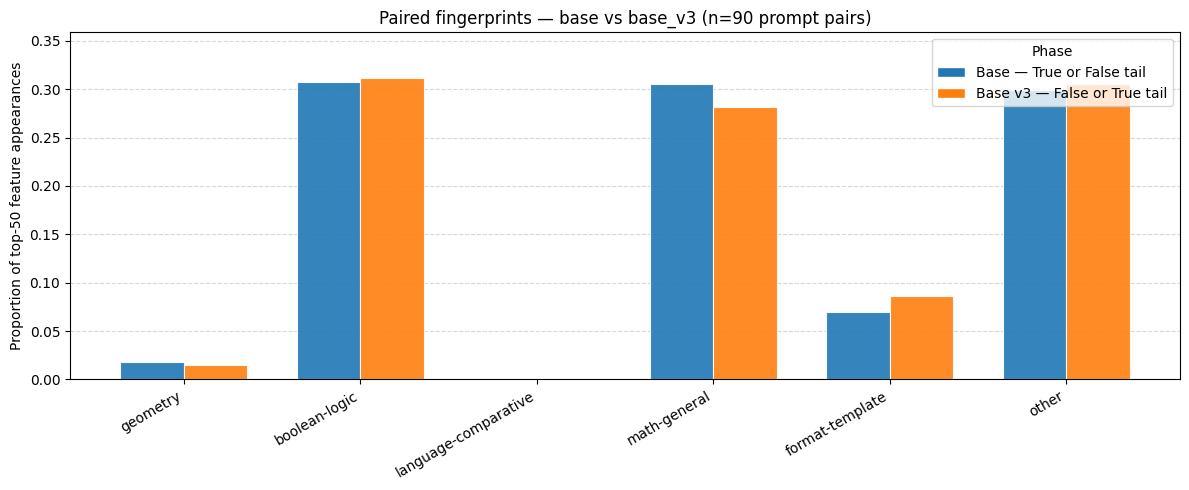

Saved: /workspace/thesis_circuit_breaker/my_work/results/figures/neuronpedia/paired_base_v3/fingerprint_delta_paired.png


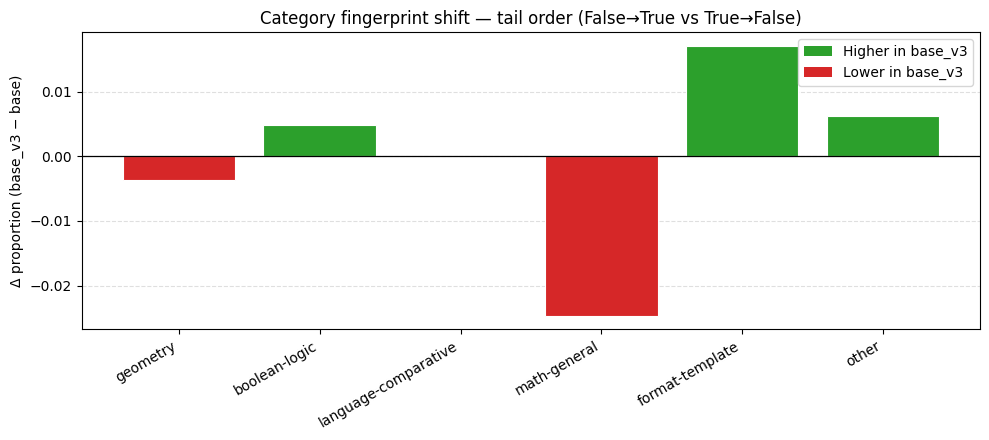

Top-50 feature Jaccard (base vs base_v3, same claim):
  mean=0.704  median=0.706  min=0.636


,num,base_id,v3_id,jaccard_top50,n_intersection,n_union,family,label,l1_category_distance
4,011,tri_v2_011,tri_v3_011,0.636364,35,55,numeric_validity,True,0.08
9,022,tri_v2_022,tri_v3_022,0.636364,35,55,numeric_validity,True,0.12
10,025,tri_v2_025,tri_v3_025,0.636364,35,55,numeric_validity,True,0.12
20,049,tri_v2_049,tri_v3_049,0.636364,35,55,numeric_validity,True,0.12
17,041,tri_v2_041,tri_v3_041,0.641509,34,53,numeric_validity,False,0.12
1,004,tri_v2_004,tri_v3_004,0.641509,34,53,numeric_validity,True,0.04
55,181,tri_v2_181,tri_v3_181,0.641509,34,53,numeric_validity,False,0.12
33,099,tri_v2_099,tri_v3_099,0.641509,34,53,numeric_validity,True,0.04


,num,base_id,v3_id,jaccard_top50,n_intersection,n_union,family,label,l1_category_distance
2,005,tri_v2_005,tri_v3_005,0.775510,38,49,numeric_validity,False,0.08
28,075,tri_v2_075,tri_v3_075,0.775510,38,49,numeric_validity,True,0.04
44,133,tri_v2_133,tri_v3_133,0.775510,38,49,numeric_validity,False,0.04
46,141,tri_v2_141,tri_v3_141,0.775510,38,49,geometry_claim,False,0.04
78,246,tri_v2_246,tri_v3_246,0.775510,38,49,numeric_validity,False,0.08
51,169,tri_v2_169,tri_v3_169,0.775510,38,49,geometry_claim,True,0.04
54,177,tri_v2_177,tri_v3_177,0.775510,38,49,geometry_claim,False,0.08
72,232,tri_v2_232,tri_v3_232,0.745098,38,51,numeric_validity,False,0.08


Saved: /workspace/thesis_circuit_breaker/my_work/results/figures/neuronpedia/paired_base_v3/jaccard_top50_histogram.png


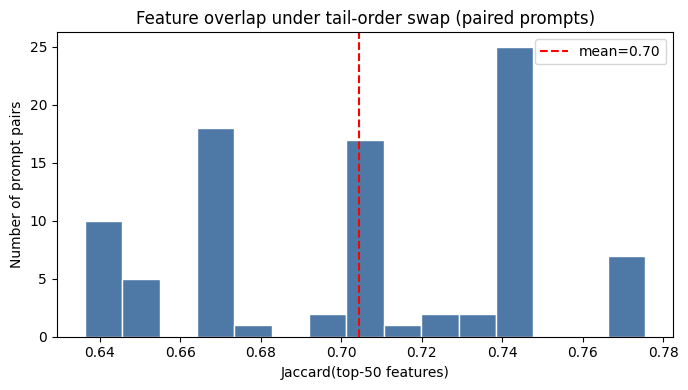

In [20]:
from matplotlib.patches import Patch

PHASE_PAIR_ORDER = ["base (paired)", "base_v3 (paired)"]
PHASE_PAIR_LABELS = {
    "base (paired)": "Base — True or False tail",
    "base_v3 (paired)": "Base v3 — False or True tail",
}
PHASE_PAIR_COLORS = {
    "base (paired)": "#1f77b4",      # blue
    "base_v3 (paired)": "#ff7f0e",   # orange
}
DELTA_INCREASE = "#2ca02c"
DELTA_DECREASE = "#d62728"

# ── Grouped bar chart (paired fingerprints) ───────────────────────────────────
phases_p = [p for p in PHASE_PAIR_ORDER if p in fp_paired]
x = np.arange(len(CATEGORIES))
width = 0.36
fig, ax = plt.subplots(figsize=(12, 5))
for i, phase in enumerate(phases_p):
    vals = [fp_paired[phase].get(c, 0) for c in CATEGORIES]
    ax.bar(
        x + (i - 0.5) * width,
        vals,
        width,
        color=PHASE_PAIR_COLORS[phase],
        alpha=0.9,
        edgecolor="white",
        linewidth=0.8,
    )
ax.set_xticks(x)
ax.set_xticklabels(CATEGORIES, rotation=30, ha="right", fontsize=10)
ax.set_ylabel("Proportion of top-50 feature appearances")
ax.set_title(f"Paired fingerprints — base vs base_v3 (n={len(pairs)} prompt pairs)")
ymax = max(fp_paired[p].get(c, 0) for p in phases_p for c in CATEGORIES) * 1.15
ax.set_ylim(0, ymax)
ax.yaxis.grid(True, linestyle="--", alpha=0.5)
ax.set_axisbelow(True)
ax.legend(
    handles=[
        Patch(facecolor=PHASE_PAIR_COLORS[p], edgecolor="white", label=PHASE_PAIR_LABELS[p])
        for p in phases_p
    ],
    title="Phase",
    loc="upper right",
)
fig.tight_layout()
p_out = PAIRED_DIR / "fingerprint_bar_paired.png"
fig.savefig(p_out, dpi=150, bbox_inches="tight")
print(f"Saved: {p_out}")
plt.show()

# ── Delta bar chart (v3 − base) ───────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 4.5))
bar_colors = [DELTA_INCREASE if v >= 0 else DELTA_DECREASE for v in fp_delta.values]
ax.bar(
    np.arange(len(CATEGORIES)),
    fp_delta.values,
    color=bar_colors,
    edgecolor="white",
    linewidth=0.8,
)
ax.axhline(0, color="black", linewidth=0.9)
ax.set_xticks(np.arange(len(CATEGORIES)))
ax.set_xticklabels(CATEGORIES, rotation=30, ha="right", fontsize=10)
ax.set_ylabel("Δ proportion (base_v3 − base)")
ax.set_title("Category fingerprint shift — tail order (False→True vs True→False)")
ax.legend(
    handles=[
        Patch(facecolor=DELTA_INCREASE, label="Higher in base_v3"),
        Patch(facecolor=DELTA_DECREASE, label="Lower in base_v3"),
    ],
    loc="upper right",
)
ax.yaxis.grid(True, linestyle="--", alpha=0.4)
ax.set_axisbelow(True)
fig.tight_layout()
p_out = PAIRED_DIR / "fingerprint_delta_paired.png"
fig.savefig(p_out, dpi=150, bbox_inches="tight")
print(f"Saved: {p_out}")
plt.show()

# ── Top-50 Jaccard per prompt pair ────────────────────────────────────────────
jaccard_rows = []
for p in pairs:
    A = _top50_feat_set(p["base_entry"])
    B = _top50_feat_set(p["v3_entry"])
    union = len(A | B)
    j = (len(A & B) / union) if union else float("nan")
    jaccard_rows.append({
        "num": p["num"],
        "base_id": p["base_id"],
        "v3_id": p["v3_id"],
        "jaccard_top50": j,
        "n_intersection": len(A & B),
        "n_union": union,
        "family": p["base_entry"].get("family"),
        "label": p["base_entry"].get("label"),
        "l1_category_distance": float(l1_dist.get(p["num"], float("nan"))),
    })

df_jaccard_paired = pd.DataFrame(jaccard_rows)
print("Top-50 feature Jaccard (base vs base_v3, same claim):")
print(
    f"  mean={df_jaccard_paired['jaccard_top50'].mean():.3f}  "
    f"median={df_jaccard_paired['jaccard_top50'].median():.3f}  "
    f"min={df_jaccard_paired['jaccard_top50'].min():.3f}"
)
display(df_jaccard_paired.sort_values("jaccard_top50").head(8))
display(df_jaccard_paired.sort_values("jaccard_top50", ascending=False).head(8))

fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(df_jaccard_paired["jaccard_top50"].dropna(), bins=15, color="#4e79a7", edgecolor="white")
ax.axvline(df_jaccard_paired["jaccard_top50"].mean(), color="red", linestyle="--",
           label=f"mean={df_jaccard_paired['jaccard_top50'].mean():.2f}")
ax.set_xlabel("Jaccard(top-50 features)")
ax.set_ylabel("Number of prompt pairs")
ax.set_title("Feature overlap under tail-order swap (paired prompts)")
ax.legend()
fig.tight_layout()
p_out = PAIRED_DIR / "jaccard_top50_histogram.png"
fig.savefig(p_out, dpi=150, bbox_inches="tight")
print(f"Saved: {p_out}")
plt.show()

> **Paired base v2 vs base v3 — short interpretation (tail-order only)**
>
> **What the chart shows**  
> Same **base model**, same **90 matched prompts** (identical triangle claim and label; only the answer instruction differs).  
> - **Blue — base v2:** “Answer with exactly one word: **True or False**.”  
> - **Orange — base v3:** “Answer with exactly one word: **False or True**.”  
>
> Bars are the **share of top-50 feature slots** in each Neuronpedia category (flat count, not attribution-weighted).
>
> **What we see**
> - **The mix is almost the same** — boolean-logic, math-general, and **other** each take ~**30%** in both tails; together they account for ~**90%** of top-feature appearances.
> - **Tiny shifts, not a new fingerprint:**
>   - **boolean-logic** — slightly **higher** with False→True (v3).
>   - **math-general** — **lower** with False→True (largest visible gap, ~3 pp).
>   - **format-template** — **higher** with False→True (~7% → ~8.5%).
>   - **geometry** — negligible in both (~1–2%); **language-comparative** — **zero** in the top-50 for both.
>
> **Key takeaways**
> 1. **Reordering “True or False” vs “False or True” does not rewrite the circuit’s semantic profile** — it nudges category proportions at the margin.  
> 2. **The model still leans on generic logic/math/catch-all features**, not triangle-specific geometry features, even when the prompt tail changes.  
> 3. **False→True wording slightly boosts format + boolean labels and trims math-general** — consistent with more emphasis on the answer-instruction tokens than on numeric/content tokens.  
> 4. **For the thesis:** treat this as a **controlled tail ablation** (same claims, different answer-slot text), not as a separate training phase; pair with **top-50 Jaccard (~0.7)** to show features overlap heavily while category mix shifts slightly.  
> 5. **Caveat:** v3 pool is **90 prompts** (not full 300 v2); comparisons are fair **within pairs**, not across the full datasets.

> **Top-50 Jaccard (base v2 vs base v3, same claim) — short interpretation**
>
> **What the chart shows**  
> For each **matched prompt pair** (same triangle claim, different answer tail: “True or False” vs “False or True”), we take the set of **(layer, feature)** in the top-50 attribution list for each version and compute **Jaccard overlap** = |intersection| / |union|.  
> - **1.0** = identical top-50 feature sets  
> - **0.0** = no shared features  
>
> **What we see**
> - **Mean Jaccard ≈ 0.70** (red dashed line) — on average, **about seven in ten** of the union of top features are shared between the two tails.
> - **All pairs sit in a fairly tight band (~0.64–0.78)** — no near-zero overlap and no near-perfect identity; the swap **always changes** the top set somewhat, but **never replaces it entirely**.
> - **Several clusters** (e.g. ~0.67, ~0.71, ~0.75) — some prompts are more stable under the tail swap, others reshuffle more of the top-50.
>
> **Key takeaways**
> 1. **The core attribution circuit is largely the same** — swapping only the answer-instruction order keeps most top features shared (~70% Jaccard).  
> 2. **The tail still matters** — the remaining ~30% of the union that differs is enough to show up as small fingerprint shifts (boolean ↑, math ↓) in the paired bar chart.  
> 3. **Stability is prompt-dependent** — spread from ~0.64 to ~0.78 means some claims are almost insensitive to tail wording, others more sensitive.  
> 4. **Together with the fingerprint bars:** same story — **mostly overlap, modest reordering** of which generic logic/math/format features rank in the top 50, not a new “triangle circuit.”  
> 5. **For the thesis:** cite this as evidence that **format/token-order at the answer slot perturbs but does not replace** the features driving True/False on these prompts.

### 12c — Position heatmaps (paired prompts only)

Same layout as Section 8, but aggregated only over the matched prompt pairs.

/tmp/ipykernel_1460/2535480299.py:14: RuntimeWarning: invalid value encountered in divide
  matrix_norm = np.where(row_sums > 0, matrix / row_sums, 0)


Saved: /workspace/thesis_circuit_breaker/my_work/results/figures/neuronpedia/paired_base_v3/position_heatmap_base_paired.png


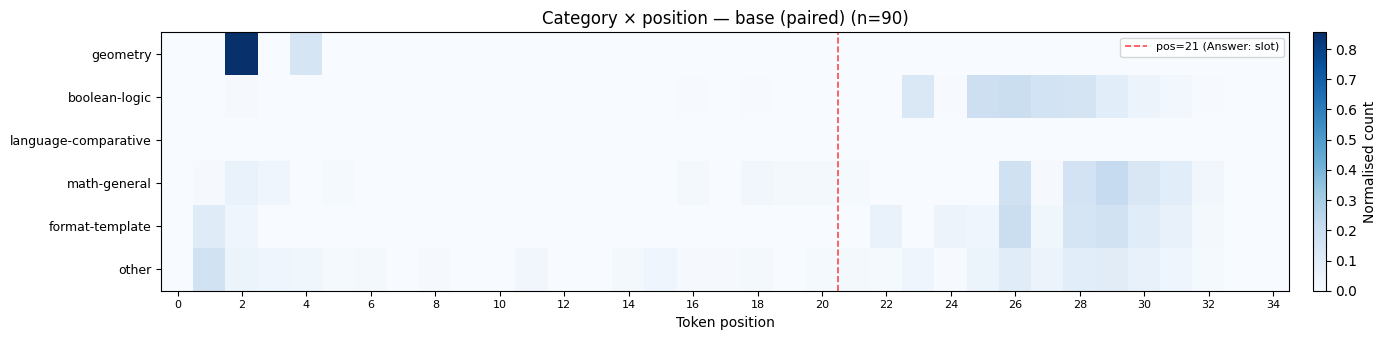

/tmp/ipykernel_1460/2535480299.py:14: RuntimeWarning: invalid value encountered in divide
  matrix_norm = np.where(row_sums > 0, matrix / row_sums, 0)


Saved: /workspace/thesis_circuit_breaker/my_work/results/figures/neuronpedia/paired_base_v3/position_heatmap_base_v3_paired.png


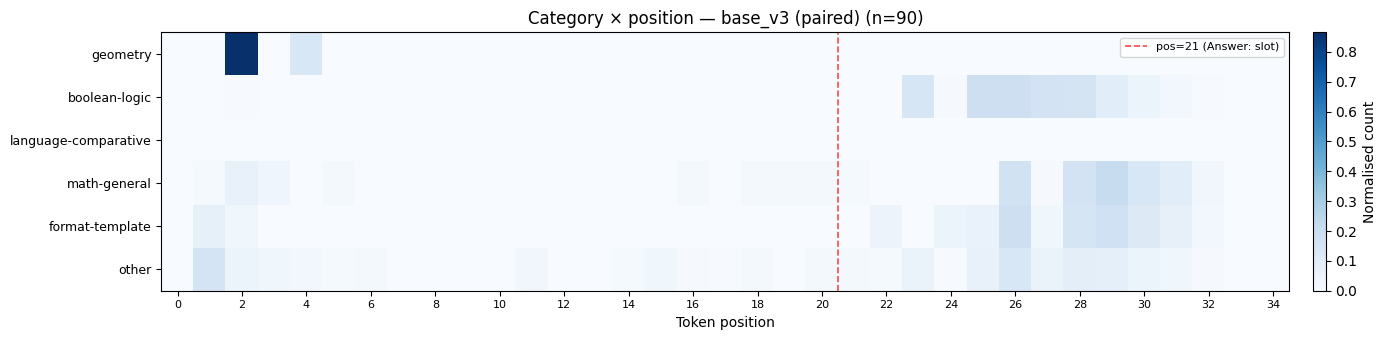

In [17]:
MAX_POS = 35

for phase_name, entries, fname in [
    ("base (paired)", paired_base_stats, "position_heatmap_base_paired.png"),
    ("base_v3 (paired)", paired_v3_stats, "position_heatmap_base_v3_paired.png"),
]:
    pos_data = compute_position_heatmap(entries, cache, override_map=override_map)
    matrix = np.zeros((len(CATEGORIES), MAX_POS))
    for r, cat in enumerate(CATEGORIES):
        for pos, count in (pos_data.get(cat) or {}).items():
            if pos < MAX_POS:
                matrix[r, pos] = count
    row_sums = matrix.sum(axis=1, keepdims=True)
    matrix_norm = np.where(row_sums > 0, matrix / row_sums, 0)

    fig, ax = plt.subplots(figsize=(14, 3.5))
    vmax = matrix_norm.max() if matrix_norm.max() > 0 else 1
    im = ax.imshow(matrix_norm, aspect="auto", cmap="Blues", vmin=0, vmax=vmax)
    ax.set_yticks(range(len(CATEGORIES)))
    ax.set_yticklabels(CATEGORIES, fontsize=9)
    ax.set_xticks(range(0, MAX_POS, 2))
    ax.set_xticklabels(range(0, MAX_POS, 2), fontsize=8)
    ax.set_xlabel("Token position")
    ax.set_title(f"Category × position — {phase_name} (n={len(entries)})")
    plt.colorbar(im, ax=ax, fraction=0.025, pad=0.02, label="Normalised count")
    ax.axvline(x=21 - 0.5, color="red", linewidth=1.2, linestyle="--", alpha=0.7,
               label="pos=21 (Answer: slot)")
    ax.legend(loc="upper right", fontsize=8)
    fig.tight_layout()
    p_out = PAIRED_DIR / fname
    fig.savefig(p_out, dpi=150, bbox_inches="tight")
    print(f"Saved: {p_out}")
    plt.show()

### 12d — Export paired comparison tables

In [18]:
df_fp_paired.to_csv(PAIRED_DIR / "fingerprint_paired.csv")
fp_delta.to_frame("delta_v3_minus_base").to_csv(PAIRED_DIR / "fingerprint_delta_paired.csv")
df_pairs.to_csv(PAIRED_DIR / "prompt_pairs.csv", index=False)
df_jaccard_paired.to_csv(PAIRED_DIR / "jaccard_top50_per_pair.csv", index=False)
l1_dist.rename("l1_category_distance").to_csv(PAIRED_DIR / "l1_distance_per_pair.csv")

print(f"Exported paired analysis to {PAIRED_DIR}")
for f in sorted(PAIRED_DIR.iterdir()):
    print(f"  {f.name}")

Exported paired analysis to /workspace/thesis_circuit_breaker/my_work/results/figures/neuronpedia/paired_base_v3
  fingerprint_bar_paired.png
  fingerprint_delta_paired.csv
  fingerprint_delta_paired.png
  fingerprint_paired.csv
  jaccard_top50_histogram.png
  jaccard_top50_per_pair.csv
  l1_distance_per_pair.csv
  position_heatmap_base_paired.png
  position_heatmap_base_v3_paired.png
  prompt_pairs.csv
